# Parte 1

In [ ]:
!pip install rdkit

^C


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
archivo = ('/content/drive/MyDrive/Delaney.csv')
df = pd.read_csv(archivo)
df

,Unnamed: 0,SMILES,Compound ID
0,0,ClCC(Cl)(Cl)Cl,"1,1,1,2-Tetrachloroethane"
1,1,CC(Cl)(Cl)Cl,"1,1,1-Trichloroethane"
2,2,ClC(Cl)C(Cl)Cl,"1,1,2,2-Tetrachloroethane"
3,3,ClCC(Cl)Cl,"1,1,2-Trichloroethane"
4,4,FC(F)(Cl)C(F)(Cl)Cl,"1,1,2-Trichlorotrifluoroethane"
...,...,...,...
1139,1139,CNC(=O)C(C)SCCSP(=O)(OC)(OC),vamidothion
1140,1140,CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C,Vinclozolin
1141,1141,CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O,Warfarin
1142,1142,Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O,Xipamide


## Un detalle...
La columna Unnamed: 0 es una columna por defecto sin nombre que enumera los compuestos. Dado que el DataFrame ya posee su propio índice, podemos eliminar esta columna.
Esto mejora la organización y evita inconsistencias al modificar el DataFrame, ya que, a diferencia de la columna Unnamed: 0, el índice se ajusta automáticamente a la cantidad de filas sin necesidad de reiniciarlo.

In [ ]:
df.drop('Unnamed: 0', axis=1, inplace=True)
df

,SMILES,Compound ID
0,ClCC(Cl)(Cl)Cl,"1,1,1,2-Tetrachloroethane"
1,CC(Cl)(Cl)Cl,"1,1,1-Trichloroethane"
2,ClC(Cl)C(Cl)Cl,"1,1,2,2-Tetrachloroethane"
3,ClCC(Cl)Cl,"1,1,2-Trichloroethane"
4,FC(F)(Cl)C(F)(Cl)Cl,"1,1,2-Trichlorotrifluoroethane"
...,...,...
1139,CNC(=O)C(C)SCCSP(=O)(OC)(OC),vamidothion
1140,CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C,Vinclozolin
1141,CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O,Warfarin
1142,Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O,Xipamide


In [ ]:
df.isna().sum() #Verificamos si el DataFrame contiene valores faltantes o nulos

,0
SMILES,0
Compound ID,0


## Busqueda de duplicados en el código
Los siguientes scripts muestran, si se encuentran, elementos duplicados dentro de la tabla de compuestos. Si hay duplicados, los elimina con el siguiente código:
```Python
df.drop_duplicates(subset='Column name', keep='first', inplace=True)
```

In [ ]:
#Buscamos duplicados en columna SMILES
from IPython.display import display
duplicates = df[df.duplicated(subset='SMILES', keep=False)]

if not duplicates.empty:
    print("Duplicados encontrados en la columna 'SMILES':")
    duplicates = duplicates.sort_values(by='SMILES')        #Ordenamos por columna
    display(duplicates)                                     #'SMILES'
else:
    print("No se encontraron duplicados en la columna 'SMILES'.")

Duplicados encontrados en la columna 'SMILES':


,SMILES,Compound ID
1046,C2c1ccccc1N(CCF)C(=O)c3ccccc23,RTI 7
1039,C2c1ccccc1N(CCF)C(=O)c3ccccc23,RTI 20
288,CCC(C)CCO,3-Methyl-2-pentanol
289,CCC(C)CCO,3-Methyl-2-pentanol
870,CCN(CC)c1c(cc(c(N)c1N(=O)=O)C(F)(F)F)N(=O)=O,Nitramine
607,CCN(CC)c1c(cc(c(N)c1N(=O)=O)C(F)(F)F)N(=O)=O,Dinitramine
668,CCOC(=O)c1ccc(N)cc1,Ethyl-p-aminobenzoate
428,CCOC(=O)c1ccc(N)cc1,Benzocaine
648,CCOC2Oc1ccc(OS(C)(=O)=O)cc1C2(C)C,Ethofumesate
649,CCOC2Oc1ccc(OS(C)(=O)=O)cc1C2(C)C,ethofumesate


In [ ]:
#Como SMILES toma por ejemplo isómeros como duplicados (que no queremos eliminar),
#filtramos por el nombre del elemento 'Compound ID'.
from IPython.display import display
duplicates = df[df.duplicated(subset='Compound ID', keep=False)]

if not duplicates.empty:
    print("Duplicados encontrados en la columna 'Compound ID':")
    duplicates = duplicates.sort_values(by='Compound ID') #Ordenamos por columna
    display(duplicates)                                   #'Compound ID'.
else:
    print("No se encontraron duplicados en la columna 'Compound ID'.")

Duplicados encontrados en la columna 'Compound ID':


,SMILES,Compound ID
288,CCC(C)CCO,3-Methyl-2-pentanol
289,CCC(C)CCO,3-Methyl-2-pentanol


In [ ]:
#Removemos duplicado 'Compound ID' del DataFrame,
#"keep='first'" indica cuál de los duplicados conservar.
df.drop_duplicates(subset='Compound ID', keep='first', inplace=True)

In [ ]:
#Chequeamos que se haya eliminado el duplicado.
duplicates2 = df[df.duplicated(subset='Compound ID', keep=False)]

if not duplicates2.empty:
    print("Duplicados encontrados en la columna 'Compound ID':")
    duplicates2 = duplicates2.sort_values(by='Compound ID')
    display(duplicates2)
else:
    print("No se encontraron duplicados en la columna 'Compound ID'.")

No se encontraron duplicados en la columna 'Compound ID'.


# Parte 2

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Lipinski import NumRotatableBonds
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def calcular_propiedades(smiles):      #Definimos función para calcular propiedades (toma como entrada 'smiles')
    mol = Chem.MolFromSmiles(smiles)      #Convierte un string 'smiles' en un objeto molécula mol (que RDKit puede procesar)
    if mol is None:
        return pd.Series([None]*4, index=['cLogP', 'molecular_weight', 'num_rotatable_bonds', 'aromatic_proportion'])  #Si el SMILES es inválido, devuelve una fila con None para cada propiedad, para q el DataFrame quede limpio y con la = estructura.

#Si el SMILES es válido utilizamos distintas funciones del modulo rdkit
    cLogP = Descriptors.MolLogP(mol)  #Logaritmo del coeficiente de partición octanol/agua (medida de lipofilicidad: qué tan soluble es la molécula en grasas vs. agua)
    molecular_weight = Descriptors.MolWt(mol)  #Peso molecular
    num_rotatable_bonds = NumRotatableBonds(mol)  #Número de enlaces rotatorios

    ring_count = Descriptors.RingCount(mol)  #Número de anillos
    num_aromatic_rings = Descriptors.NumAromaticRings(mol)  #Número anillos aromáticos
    aromatic_proportion = num_aromatic_rings / ring_count if ring_count > 0 else 0

    return pd.Series([cLogP, molecular_weight, num_rotatable_bonds, aromatic_proportion], index=['cLogP', 'molecular_weight', 'num_rotatable_bonds', 'aromatic_proportion'])  #Devuelve las 4 propiedades químicas como una fila tipo Series de pandas

df.loc[:, ['cLogP', 'molecular_weight', 'num_rotatable_bonds', 'aromatic_proportion']] = (df['SMILES'].apply(calcular_propiedades)) #Añadimos las Series al DataFrame a partir de la columna SMIILES, : indica q se aplica a todas las filas
display(df)

,SMILES,Compound ID,cLogP,molecular_weight,num_rotatable_bonds,aromatic_proportion
0,ClCC(Cl)(Cl)Cl,"1,1,1,2-Tetrachloroethane",2.59540,167.850,0.0,0.0
1,CC(Cl)(Cl)Cl,"1,1,1-Trichloroethane",2.37650,133.405,0.0,0.0
2,ClC(Cl)C(Cl)Cl,"1,1,2,2-Tetrachloroethane",2.59380,167.850,1.0,0.0
3,ClCC(Cl)Cl,"1,1,2-Trichloroethane",2.02890,133.405,1.0,0.0
4,FC(F)(Cl)C(F)(Cl)Cl,"1,1,2-Trichlorotrifluoroethane",2.91890,187.375,1.0,0.0
...,...,...,...,...,...,...
1139,CNC(=O)C(C)SCCSP(=O)(OC)(OC),vamidothion,1.98820,287.343,8.0,0.0
1140,CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C,Vinclozolin,3.42130,286.114,2.0,0.5
1141,CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O,Warfarin,3.60960,308.333,4.0,1.0
1142,Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O,Xipamide,2.56214,354.815,3.0,1.0


## Predecir el logaritmo de solubilidad acuosa (LogS)
Empleando los cuatros parametros del punto anterior se debe obtener LogS y añadir el dato en una columna a la tabla.
El siguiente script puede hacerlo y mostrar el resultado.

In [ ]:
!pip install mordred

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.8/128.8 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 17.6 MB/s eta 0:00:00
  Created wheel for mordred: filename=mordred-1.2.0-py3-none-any.whl size=176718 sha256=ca3b4b7da7959b02a857d658b2b17846b6d0ea1181eb8b1930c9fc288cea08ee
  Stored in directory: /root/.cache/pip/wheels/8b/30/0b/84e3f6775306e74cf5957ee4d16b10bf3927dcec44cc23d5f2
Successfully built mordred
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: networkx
    Found existing installation: networkx 3.5
    Uninstalling networkx-3.5:
      Successfully uninstalled networkx-3.5
ERROR: pip's dependency resolver does not currently t

In [ ]:
from mordred import Calculator, LogS

calc = Calculator([LogS])
def calc_properties(smiles):
  mol = Chem.MolFromSmiles(smiles)
  try:
        logs = list(calc(mol).values())[0]
  except Exception:
        logs = None
  return pd.Series([logs], index=['LogS'])
df.loc[:, ['LogS']] = round(df['SMILES'].apply(calc_properties),3)
display(df)

,SMILES,Compound ID,cLogP,molecular_weight,num_rotatable_bonds,aromatic_proportion,LogS
0,ClCC(Cl)(Cl)Cl,"1,1,1,2-Tetrachloroethane",2.59540,167.850,0.0,0.0,-2.790
1,CC(Cl)(Cl)Cl,"1,1,1-Trichloroethane",2.37650,133.405,0.0,0.0,-2.130
2,ClC(Cl)C(Cl)Cl,"1,1,2,2-Tetrachloroethane",2.59380,167.850,1.0,0.0,-2.434
3,ClCC(Cl)Cl,"1,1,2-Trichloroethane",2.02890,133.405,1.0,0.0,-2.147
4,FC(F)(Cl)C(F)(Cl)Cl,"1,1,2-Trichlorotrifluoroethane",2.91890,187.375,1.0,0.0,-2.665
...,...,...,...,...,...,...,...
1139,CNC(=O)C(C)SCCSP(=O)(OC)(OC),vamidothion,1.98820,287.343,8.0,0.0,-2.003
1140,CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C,Vinclozolin,3.42130,286.114,2.0,0.5,-3.677
1141,CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O,Warfarin,3.60960,308.333,4.0,1.0,-4.965
1142,Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O,Xipamide,2.56214,354.815,3.0,1.0,-4.497


# Parte 3

## Histogramas y carpeta 'Plots'.
La siguiente línea de código muestra la importación de una serie de librerías que serán empleadas para graficar distintos histogramas de las distribuciones de algunas columnas de los compuestos. Los gráficos serán posteriormente exportados a .png y guardados en la carpeta 'Plots'. Luego, estos seran empleados en la presentación PowerPoint.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os #Librería que sirve para interactar con el sistema operativo

### Histograma pesos moleculares
Este script realiza un gráfico del histograma de la distribución de los pesos moleculares de los compuestos y luego los exporta a un archivo de imagen (.png) para mostrar en el PowerPoint.

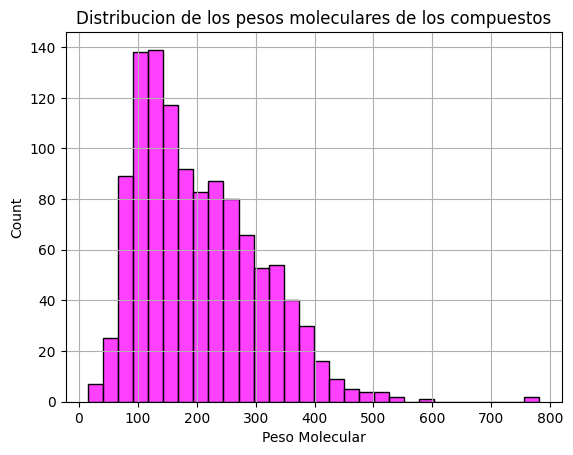

In [ ]:
#Graficamos histograma de los pesos moleculares
data = df['molecular_weight'] #Extramos columna molecular_weight del DataFrame
sns.histplot(df['molecular_weight'], color='magenta', bins=30, edgecolor="black")
plt.title('Distribucion de los pesos moleculares de los compuestos')
plt.xlabel('Peso Molecular')
plt.ylabel('Count') #Conteo de compuestos en cada clase
plt.grid(True)  #Agregamos grilla de fondo

#Guardamos en una carpeta las fotos del histograma
output_dir = "Plots"  #Definimos el nombre de la carpeta donde se guardará el gráfico
os.makedirs(output_dir, exist_ok=True)  #Crea la carpeta solo si no existe ya
plt.savefig(os.path.join(output_dir, "molecular_weights_histogram.png"))

plt.show()

### Histograma proporcion de anillos aromáticos
Este script realiza un gráfico del histograma de la distribución de la proporción de anillos aromáticos de los compuestos y luego los exporta a un archivo de imagen (.png) para mostrar en el PowerPoint.

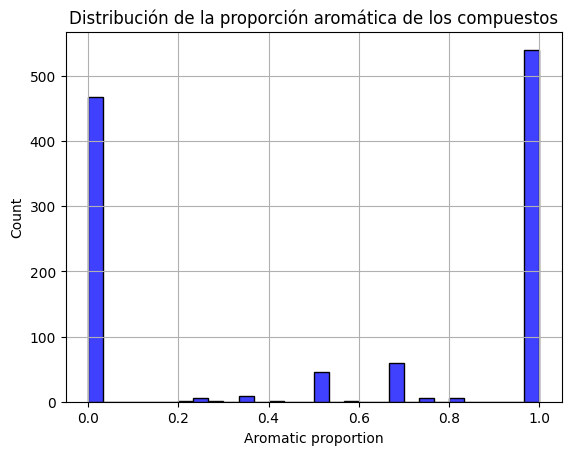

In [ ]:
#Repetimos proceso para el resto de propiedades
data = df['aromatic_proportion']
sns.histplot(df['aromatic_proportion'], color='blue', bins=30, edgecolor="black") #Bins indica cantidad de clases
plt.title('Distribución de la proporción de los anillos aromáticos')
plt.xlabel("Proporción de anillos aromáticos")
plt.ylabel('Count')
plt.grid(True)

output_dir = "Plots"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "aromatic_proportion_histogram.png"))

plt.show()

### Histograma número de enlaces rotables
Este script muestra la distribución de enlaces rotables de los compuestos. Luego los imprimer en una imagen .png para colocar en el PowerPoint.

In [ ]:
data = df['num_rotatable_bonds']
sns.histplot(df['num_rotatable_bonds'], color='green', bins=30, edgecolor="black")
plt.title('Distribución de los enlaces rotables de los compuestos')
plt.xlabel("Enlaces Rotables")
plt.ylabel('Count')
plt.grid(True)

output_dir = "Plots"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "num_rotatable_bonds_histogram.png"))

plt.show()

NameError: name 'df' is not defined

### Histograma cLogP
Esta linea decódigo muestra el histograma de la distribución del coeficiente de particion de octanol-agua (cLogP). También lo exporta a un archivo .png para ser presentado posteriormente en el PowerPoint de la presentación.

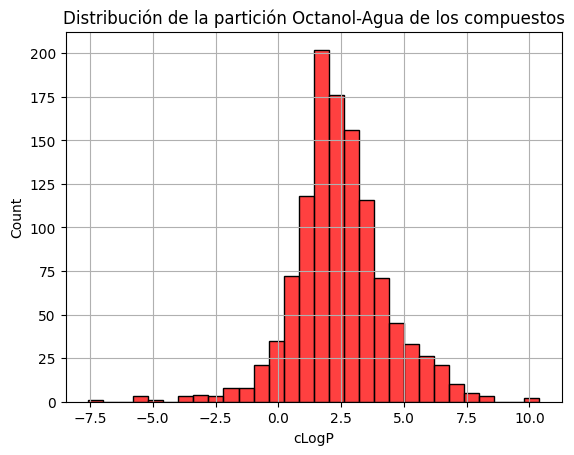

In [ ]:
data = df['cLogP']
sns.histplot(df['cLogP'], color='red', bins=30, edgecolor="black")
plt.title('Distribución de la partición octanol-agua de los compuestos')
plt.xlabel("cLogP")
plt.ylabel('Count')
plt.grid(True)

output_dir = "Plots"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "cLogP_histogram.png"))

plt.show()

### Histograma LogS
Esta linea decódigo muestra el histograma de la distribución del logaritomo de la solubilidad acuosa (LogS). También lo exporta a un archivo .png para ser presentado posteriormente en el PowerPoint de la presentación.

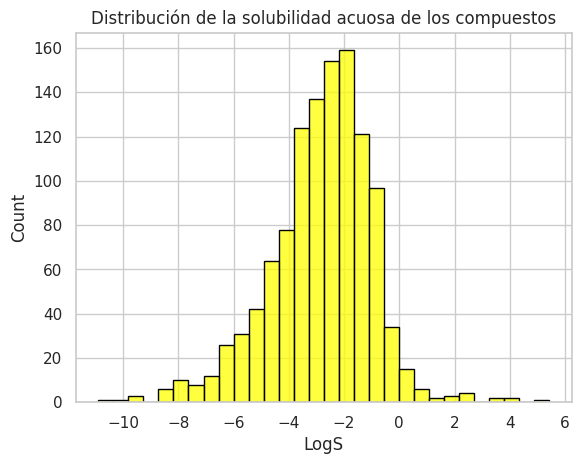

In [ ]:
data = df['LogS']
sns.histplot(df['LogS'], color='yellow', bins=30, edgecolor="black")
plt.title('Distribución de la solubilidad acuosa de los compuestos')
plt.xlabel("LogS")
plt.ylabel('Count')
plt.grid(True)

output_dir = "Plots"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "LogS_histogram.png"))

plt.show()

##Exploración de datos
En esta sección utilizaremos distintas herramientas de la estadistica descriptiva para explorar los datos.

In [ ]:
df.describe()

,cLogP,molecular_weight,num_rotatable_bonds,aromatic_proportion,LogS
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,2.450038,204.721311,2.173228,0.539770,-2.832219
std,1.866569,102.620605,2.628435,0.471109,1.862997
min,-7.571400,16.043000,0.000000,0.000000,-10.898000
25%,1.414900,122.147000,0.000000,0.000000,-3.810000
50%,2.340600,184.020000,1.000000,0.666667,-2.599000
75%,3.410750,270.930500,3.000000,1.000000,-1.641500
max,10.388600,780.949000,23.000000,1.000000,5.428000


In [ ]:
df[df['molecular_weight'] == df['molecular_weight'].min()]

,SMILES,Compound ID,cLogP,molecular_weight,num_rotatable_bonds,aromatic_proportion,LogS
800,C,Methane,0.6361,16.043,0.0,0.0,0.483


In [ ]:
df[df['molecular_weight'] == df['molecular_weight'].max()]

,SMILES,Compound ID,cLogP,molecular_weight,num_rotatable_bonds,aromatic_proportion,LogS
593,CC1OC(CC(O)C1O)OC2C(O)CC(OC2C)OC8C(O)CC(OC7CCC...,"Digoxin (L1=41,8mg/mL, L2=68,2mg/mL, Z=40,1mg/mL)",2.2181,780.949,7.0,0.0,-1.426


### Outliers
Este código nos permite tener información acerca de los outliers, que son observaciones que se desvían significativamente del resto de los datos en un conjunto.
Está descripta como una funcion que analiza el primer y tercer cuartil y los resta, establece los limites superior e inferior y devuelve los outliers.

In [ ]:
#Definimos una funcion que pueda detectar outliers en una serie usando
#rango intercuartil
def detectar_outliers_iqr(serie): #Función detectar_outliers_iqr con entrada serie
    Q1 = serie.quantile(0.25) #Llamamos al cuantil sobre la serie
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inferior = Q1 - 1.5 * IQR
    lim_superior = Q3 + 1.5 * IQR
    outliers = serie[(serie < lim_inferior) | (serie > lim_superior)] #Filtramos la
    return outliers                                            #serie para quedarnos
                                                              #con valores atípicos

In [ ]:
outliers_mw = detectar_outliers_iqr(df['molecular_weight']) #Ejecutamos la funcion usando molecular_weight como entrada y guardamos datos en variable outliers_mw
print('Nº de outliers en molecular_weight:', len(outliers_mw))  #'len' devuelve la longitud de elementos del objeto
display(outliers_mw)

Nº de outliers en molecular_weight: 10


,molecular_weight
116,498.662
444,527.414
559,505.206
592,764.950
593,780.949
673,588.562
700,502.920
843,545.546
881,511.581
1021,504.438


In [ ]:
#Hacemos lo mismo con el resto de columnas (excepto aromatic_proportion que cuyos valores van entre 0 y 1)
outliers_nrb = detectar_outliers_iqr(df['num_rotatable_bonds'])
print('Nº de outliers en num_rotatable_bonds:', len(outliers_nrb))
display(outliers_nrb)


Nº de outliers en num_rotatable_bonds: 54


,num_rotatable_bonds
77,8.0
79,10.0
84,14.0
105,16.0
109,13.0
115,12.0
259,8.0
280,9.0
283,8.0
301,10.0


In [ ]:
outliers_cLogP = detectar_outliers_iqr(df['cLogP'])
print('Nº de outliers en cLogP:', len(outliers_cLogP))
display(outliers_cLogP)

Nº de outliers en cLogP: 57


,cLogP
116,9.88760
117,8.58080
118,7.27400
119,8.58080
120,7.27400
122,7.92740
123,7.92740
124,7.27400
125,6.62060
126,6.62060


In [ ]:
outliers_LogS = detectar_outliers_iqr(df['LogS'])
print('Nº de outliers en LogS:', len(outliers_LogS))
display(outliers_LogS)

Nº de outliers en LogS: 41


,LogS
116,-10.898
117,-9.435
118,-7.958
119,-9.435
120,-7.958
122,-8.698
123,-8.698
124,-7.958
125,-7.213
126,-7.213


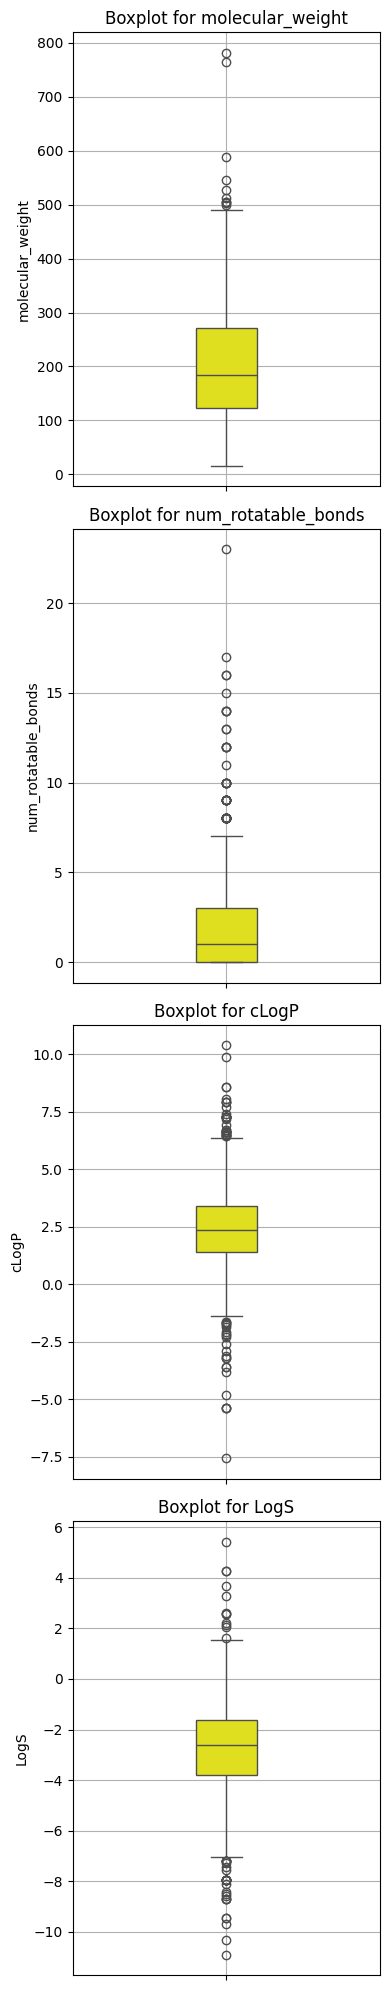

In [ ]:
#Graficamos los boxplots
import matplotlib.pyplot as plt
import seaborn as sns

columnas = ['molecular_weight', 'num_rotatable_bonds', 'cLogP', 'LogS']

plt.figure(figsize=(4, 20))  #Creamos una figura general que va a contener todos los subgráficos

for i, col in enumerate(columnas):  #Iteramos por cada variable
    plt.subplot(len(columnas), 1, i + 1)  #Creamos un subplot en la fila i+1 (porque Python empieza en 0), y 1 columna

    sns.boxplot(data=df, y=col, color='yellow', width=0.2)  #Como no especificamos x, se asume que todos los datos pertenecen a una sola categoría (boxplot centrado)
                                                            #Reducimos ancho
    plt.title('Boxplot for '+ str(col))
    plt.grid(True)

#Guardamos graficos
output_dir = "Plots"
plt.savefig(os.path.join(output_dir, "BoxPlots.png"))

plt.tight_layout()
plt.show()

### Gráfica de los pesos moleculares de los compuestos
Los compuestos han sido graficados en un histograma diferenciando con colores los pesos moleculares por
- *anaranjado* :peso molecular bajo
- *verde* :peso molecular medio
- *azul* :peso molecular alto

La siguiente línea muestra el criterio para la clasificacion de los pesos moleculares:

```Python
def clasificacion_mw(x):
    if x < 120:
        return 'MW_low'
    elif x >= 180:
        return 'MW_high'
    else:
        return 'MW_medium'
```
Menores a 120 g/mol: bajos, menores a 180 g/mol: medios y los restantes valores superiores a 180 se consideran de alto peso molecular.

In [ ]:
def clasificacion_mw(x):
    if x < 120:
        return 'MW_low'
    elif x >= 180:
        return 'MW_high'
    else:
        return 'MW_medium'

#Aplicamos función clasificacion_mw a cada valor de la columna 'molecular_weight'
#Generamos nueva columna con categoría resultante
df['mw_category'] = df['molecular_weight'].apply(clasificacion_mw)
df

,SMILES,Compound ID,cLogP,molecular_weight,num_rotatable_bonds,aromatic_proportion,LogS,mw_category
0,ClCC(Cl)(Cl)Cl,"1,1,1,2-Tetrachloroethane",2.59540,167.850,0.0,0.0,-2.790,MW_medium
1,CC(Cl)(Cl)Cl,"1,1,1-Trichloroethane",2.37650,133.405,0.0,0.0,-2.130,MW_medium
2,ClC(Cl)C(Cl)Cl,"1,1,2,2-Tetrachloroethane",2.59380,167.850,1.0,0.0,-2.434,MW_medium
3,ClCC(Cl)Cl,"1,1,2-Trichloroethane",2.02890,133.405,1.0,0.0,-2.147,MW_medium
4,FC(F)(Cl)C(F)(Cl)Cl,"1,1,2-Trichlorotrifluoroethane",2.91890,187.375,1.0,0.0,-2.665,MW_high
...,...,...,...,...,...,...,...,...
1139,CNC(=O)C(C)SCCSP(=O)(OC)(OC),vamidothion,1.98820,287.343,8.0,0.0,-2.003,MW_high
1140,CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C,Vinclozolin,3.42130,286.114,2.0,0.5,-3.677,MW_high
1141,CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O,Warfarin,3.60960,308.333,4.0,1.0,-4.965,MW_high
1142,Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O,Xipamide,2.56214,354.815,3.0,1.0,-4.497,MW_high


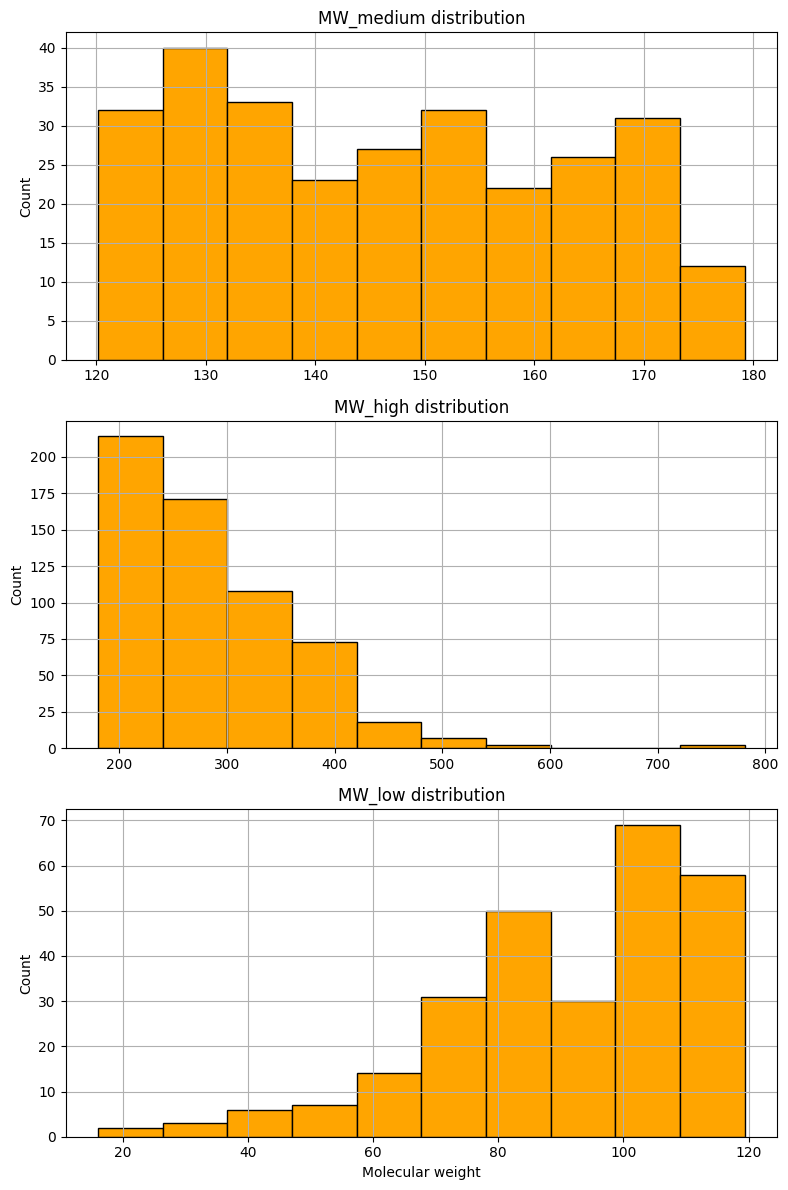

In [ ]:
import matplotlib.pyplot as plt

categories = df['mw_category'].unique() #Extraemos las categorías únicas de la columna 'mw_category' del DataFrame
fig, axs = plt.subplots(len(categories), 1, figsize=(8, 4 * len(categories))) #Creamos una figura (fig) y un conjunto de ejes (axs) para los subgráficos
                                                                              #plt.subplots(nrows, ncols, figsize=(ancho, alto))
                                                                                #len(categories) es el número de filas de gráficos (uno por categoría)
                                                                                #1 indica que será una sola columna de gráficos
                                                                                #figsize=(8, 4*len(categories)) define el tamaño total de la figura

if len(categories) == 1:
    axs = [axs]         #Aseguramos que axs sea siempre una lista aunque haya una sola categoría (para poder hacer el zip dsp)

for ax, category in zip(axs, categories): #Definimos iteradores ax y category para axs (graficos) y categories (categoría correspondiente) respectivamente
    subset = df[df['mw_category'] == category]  #Guardamos en la variable subset un pedazo del DataFrame, que contiene solo las filas pertenecientes a la categoría sobre la que se está iterando
    ax.hist(subset['molecular_weight'], color='orange', edgecolor='black') #En el subgráfico ax, dibujamos un histograma con los valores de la columna molecular_weight del subconjunto subset
    ax.set_title(str(category) + ' distribution')
    ax.set_ylabel('Count')
    ax.grid(True)

axs[-1].set_xlabel('Molecular weight')  #Etiquetamos X solo en el último grafico

plt.tight_layout()  #Ajustamos los espacios entre gráficos para que no se superpongan los textos
plt.show()

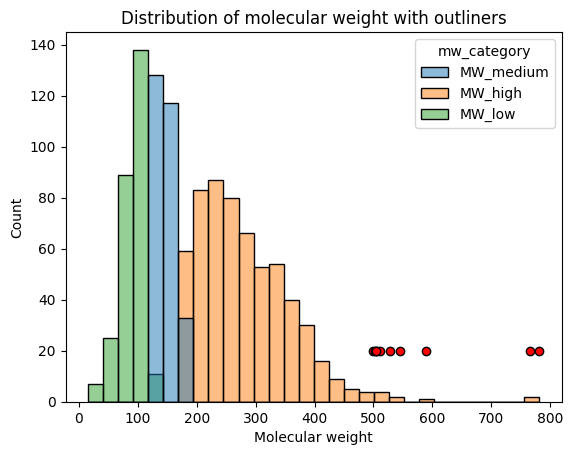

In [ ]:
#Histograma con categorías
sns.histplot(data=df, x='molecular_weight', hue='mw_category', bins=30, edgecolor='black')

#Añadir los outliers como puntos rojos arriba del histograma
plt.scatter(outliers_mw, [20]*len(outliers_mw), color='red', edgecolor='black')

plt.title('Distribution of molecular weight with outliners')
plt.xlabel('Molecular weight')
plt.ylabel('Count')

plt.show()

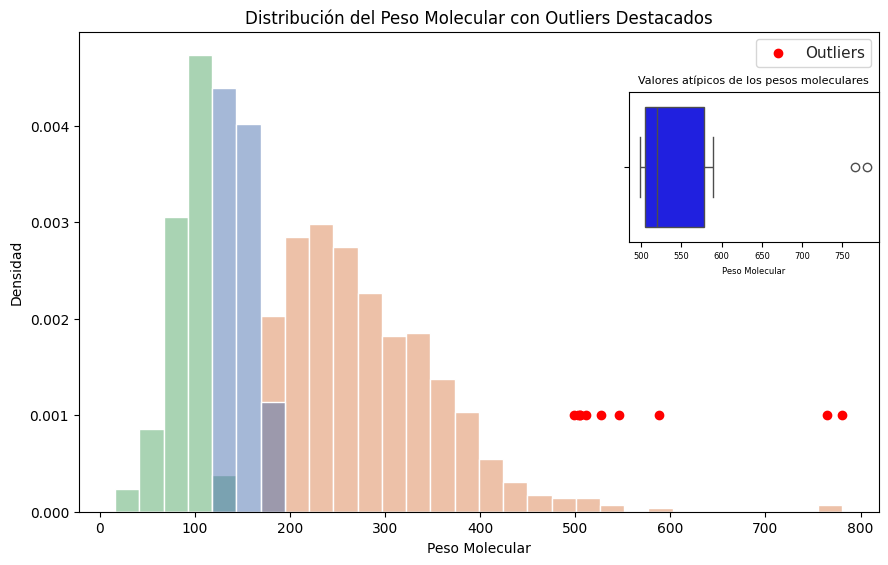

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear figura principal con dos ejes
fig = plt.figure(figsize=(10,6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])  # Eje principal para histograma
inset = fig.add_axes([0.65, 0.55, 0.25, 0.25])  # Eje insertado para boxplot

# Boxplot en el eje insertado
sns.boxplot(x=outliers_mw, ax=inset, color='blue')
inset.set_title("Valores atípicos de los pesos moleculares", fontsize=8)
inset.set_xlabel('Peso Molecular', fontsize=6)
inset.tick_params(axis='x', labelsize=6)

# Histograma con categorías en el eje principal
sns.set_theme(style="whitegrid")
sns.histplot(data=df, x='molecular_weight', hue='mw_category', bins=30, ax=ax, kde=False, stat='density')

# Puntos rojos para los outliers (con label)
ax.scatter(outliers_mw, [0.001]*len(outliers_mw), color='red', label='Outliers', zorder=10)

# Títulos y etiquetas
ax.set_title('Distribución del Peso Molecular con Outliers Destacados')
ax.set_xlabel('Peso Molecular')
ax.set_ylabel('Densidad')

# Agregar leyenda SOLO en el gráfico principal
ax.legend()

plt.show()

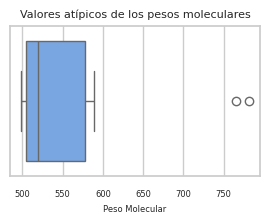

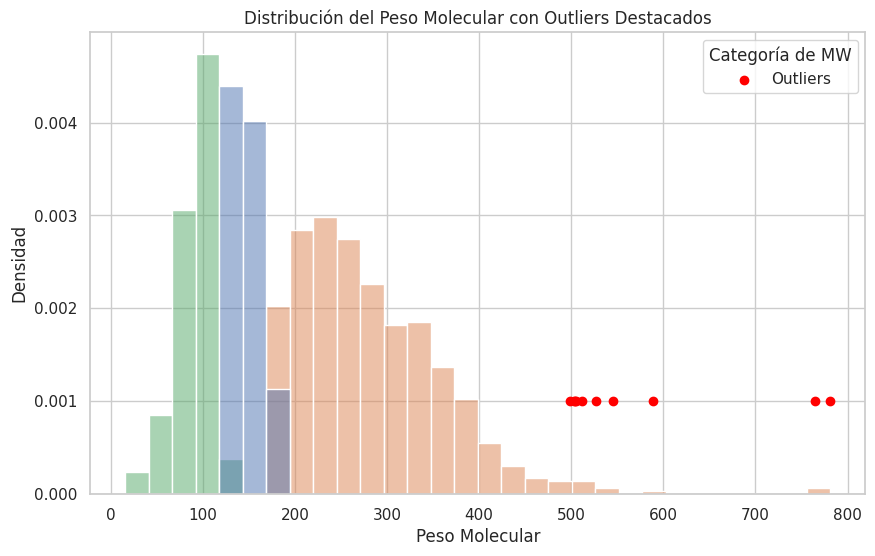

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

#Detectar outliers usando IQR
Q1 = df['molecular_weight'].quantile(0.25)
Q3 = df['molecular_weight'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
outliers = df[(df['molecular_weight'] < lim_inf) | (df['molecular_weight'] > lim_sup)]

#Boxplot de outliers. Grafica como un inserto del grafico principal.
fig = plt.figure(figsize=(10,6))
inset = fig.add_axes([0.65, 0.55, 0.25, 0.25])  #[x, y, width, height]
if not outliers.empty:
    sns.boxplot(x=outliers['molecular_weight'], ax=inset, color='#68a4f1')
    inset.set_title("Valores atípicos de los pesos moleculares", fontsize=8)
    inset.set_xlabel('Peso Molecular', fontsize=6)
    inset.tick_params(axis='x', labelsize=6)
else:
    inset.set_title("No Outliers", fontsize=8)
    inset.axis('off') #Oculta el eje si no hay valores anómalos.
#Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

#Histograma con categorías
sns.histplot(data=df, x='molecular_weight', hue='mw_category', bins=30, kde=False, stat='density')

#Añadir los outliers como puntos rojos arriba del histograma
plt.scatter(outliers['molecular_weight'], [0.001]*len(outliers), color='red', label='Outliers', zorder=10)

plt.title('Distribución del Peso Molecular con Outliers Destacados')
plt.xlabel('Peso Molecular')
plt.ylabel('Densidad')
plt.legend(title='Categoría de MW')
plt.show()

## Visualización de moléculas con RDkit
Este código selecciona tres moleculas al azar de las tres categorías preestablecidas para el peso molecular (bajo, medio y alto) y las presenta para su visualización. Muestra además a qué grupo pertenecen con una leyenda debajo.

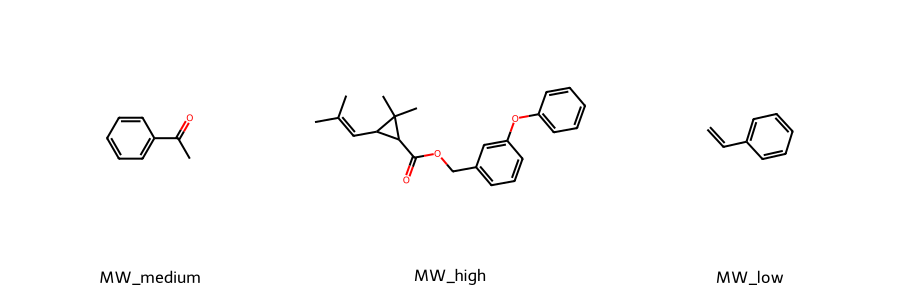

In [ ]:
import random
from rdkit import Chem
from rdkit.Chem import Draw

#Seleccionamos una molecula aleatoria por grupo
mol_ejemplares = {}  #Creamos diccionario vacío

for grupo in df['mw_category'].unique():  #Iteramos por cada categoría única de la columna mw_category
    subset = df[df['mw_category'] == grupo] #Guardamos en la variable subset un pedazo del DataFrame, que contiene solo las filas pertenecientes a la categoría sobre la que se está iterando
    random_index = random.randint(0, len(subset) - 1) #Elegimos una molecula aleatoria del subset
    muestra = subset.iloc[[random_index]] #Tomamos la fila correspondiente al índice elegido (como un DataFrame)
    smiles = muestra['SMILES'].values[0]  #Extraemos el string SMILES de la molécula elegida
    mol = Chem.MolFromSmiles(smiles)  #Convertimos ese SMILES a un objeto molécula RDKit
    mol_ejemplares[grupo] = mol #Guardamos esa molécula en el diccionario mol_ejemplares usando como clave su categoría

#Mostramos las moléculas seleccionadas con grilla de imágenes
Draw.MolsToGridImage(
    list(mol_ejemplares.values()),  #Generamos una lista (argumento de MolsToGridImage) con las moleculas del diccionario mol_ejemplares
    legends=mol_ejemplares.keys(),  #Con su leyenda correspondiente (categoría)
    subImgSize=(300, 300)
)

In [ ]:
df.to_excel('delaney_data.xlsx', index=True) #Exportamos el DataFrame df junto con su index a un archivo Excel llamado 'delaney_data.xlsx'